Nombre: Felipe Aravena 
Rut: 21.128.400-5
Fecha: 06-05-2026

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Configuración global de Seaborn
sns.set_theme(
style='whitegrid',
palette='muted',
font_scale=1.2
)
# Carga del dataset
df = pd.read_csv('cafeteria_universitaria_s8.csv')

In [2]:
df.head()

,facultad,turno,dia_semana,tipo_pedido,metodo_pago,nivel_academico,semana_mes,gasto_total,tiempo_espera_min,calificacion_servicio,items_pedido,propina_porcentaje
0,Ciencias,Mañana,Jueves,Almuerzo,Débito,Postgrado,1,4.28,8.6,4.8,3,7.7
1,Ciencias,Mañana,Jueves,Almuerzo,QR,Postgrado,2,4.98,9.0,3.9,3,13.6
2,Ciencias,Mañana,Jueves,Snack,Débito,Postgrado,2,3.42,10.7,3.3,1,12.2
3,Ciencias,Mañana,Jueves,Almuerzo,Débito,Postgrado,2,3.64,9.5,4.0,1,5.3
4,Ciencias,Mañana,Jueves,Bebida,Débito,Postgrado,3,1.17,5.7,4.8,2,7.6


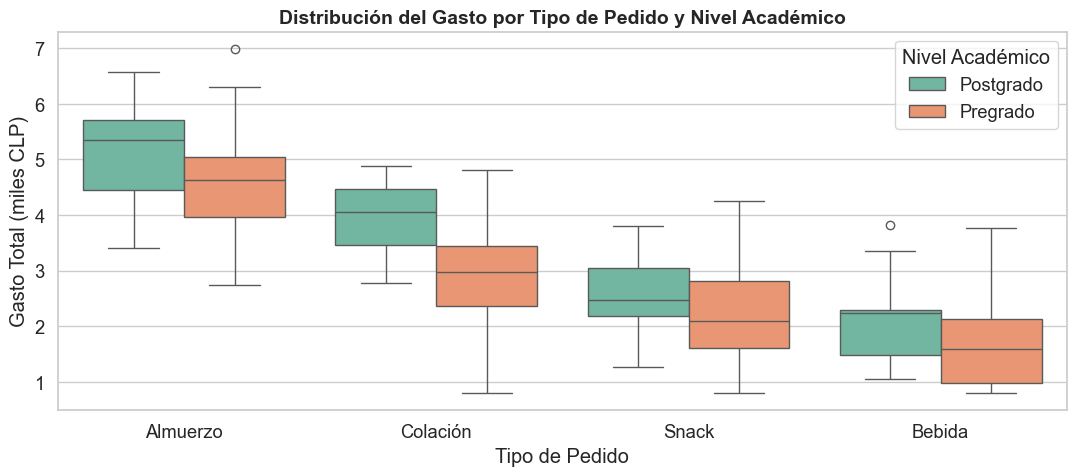

In [3]:
#Ejercicio 1: Diagrama de Caja (Boxplot)
fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(
    data=df,             
    x='tipo_pedido',      
    y='gasto_total',      
    hue='nivel_academico',
    palette='Set2',       
    order=['Almuerzo', 'Colación', 'Snack', 'Bebida'], 
    ax=ax
)

ax.set_title('Distribución del Gasto por Tipo de Pedido y Nivel Académico',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Pedido')
ax.set_ylabel('Gasto Total (miles CLP)')
ax.legend(title='Nivel Académico', loc='upper right')

plt.tight_layout()
plt.show()           

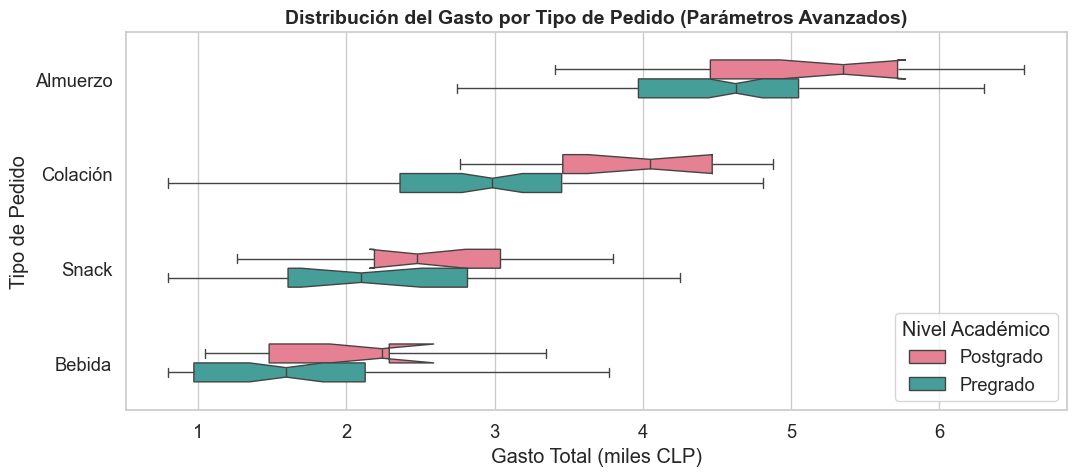

In [4]:
#cambios en los parametros 
fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(
    data=df,
    x='gasto_total',       
    y='tipo_pedido',        
    hue='nivel_academico',
    palette='husl',        
    order=['Almuerzo', 'Colación', 'Snack', 'Bebida'],
    showfliers=False,      
    notch=True,           
    width=0.4,          
    orient='h',            
    ax=ax
)

ax.set_title('Distribución del Gasto por Tipo de Pedido (Parámetros Avanzados)', fontsize=14, fontweight='bold')
ax.set_xlabel('Gasto Total (miles CLP)')
ax.set_ylabel('Tipo de Pedido')
ax.legend(title='Nivel Académico', loc='lower right')

plt.tight_layout()
plt.show()

Efectos observados 


showfliers=False : Elimina visualmente del gráfico los puntos individuales que representan los valores atípicos (outliers), dejando solo los bigotes y las cajas.

notch=True : Crea un estrechamiento (muesca) en torno a la línea de la mediana de cada caja, lo que sirve para representar visualmente el intervalo de confianza de dicha mediana.

width=0.4 : Disminuye el grosor o ancho de las cajas rectangulares, lo que aumenta el espacio en blanco entre ellas y reduce la saturación visual.

orient='h': Cambia la orientación del gráfico completo de vertical a horizontal. (Nota: para que funcione, fue necesario invertir las variables de los ejes X e Y).

palette='husl' : Cambia el esquema de colores por defecto a la paleta 'husl', aplicando tonos más vibrantes que están espaciados uniformemente.


Preguntas de analisis 


1.- ¿Qué tipo de pedido presenta la mayor variabilidad en el gasto total? Justifique utilizando el IQR visual.
  
El tipo de pedido "Almuerzo" presenta la mayor variabilidad en el gasto total. Esto se evidencia visualmente debido a que su Rango Intercuartílico (IQR) la altura de la caja es el más extenso de las cuatro categorías.

2.- ¿Se observan outliers en alguna categoría? Si es así, ¿en qué tipo de pedido y nivel académico aparecen?

Sí, se observan valores atípicos representados como puntos individuales fuera de los bigotes de las cajas. Destacan principalmente en la categoría "Almuerzo" para estudiantes de Pregrado. También se aprecian outliers superiores en la categoría "Bebida" para estudiantes de Postgrado.

3.- ¿Existe una diferencia sistemática en el gasto entre estudiantes de Pregrado y
Postgrado? ¿En qué categorías es más evidente?

Existe una diferencia sistemática. Las medianas del nivel Postgrado se sitúan por encima de las de Pregrado en la mayoría de los casos, siendo particularmente evidente en las categorías de "Almuerzo" y "Colación".

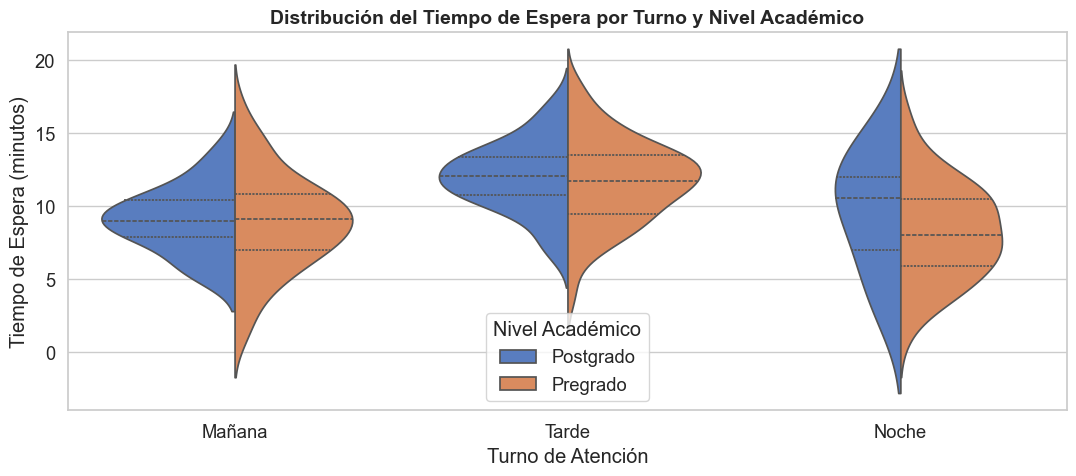

In [5]:
#Ejercicio 2: Diagrama de Violín (Violinplot) 
fig, ax = plt.subplots(figsize=(11, 5))

sns.violinplot(
    data=df,
    x='turno',
    y='tiempo_espera_min',
    hue='nivel_academico',
    split=True,
    inner='quartile', 
    palette='muted',
    order=['Mañana', 'Tarde', 'Noche'],
    ax=ax
)

ax.set_title('Distribución del Tiempo de Espera por Turno y Nivel Académico',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Turno de Atención')
ax.set_ylabel('Tiempo de Espera (minutos)')
ax.legend(title='Nivel Académico')

plt.tight_layout()
plt.show()

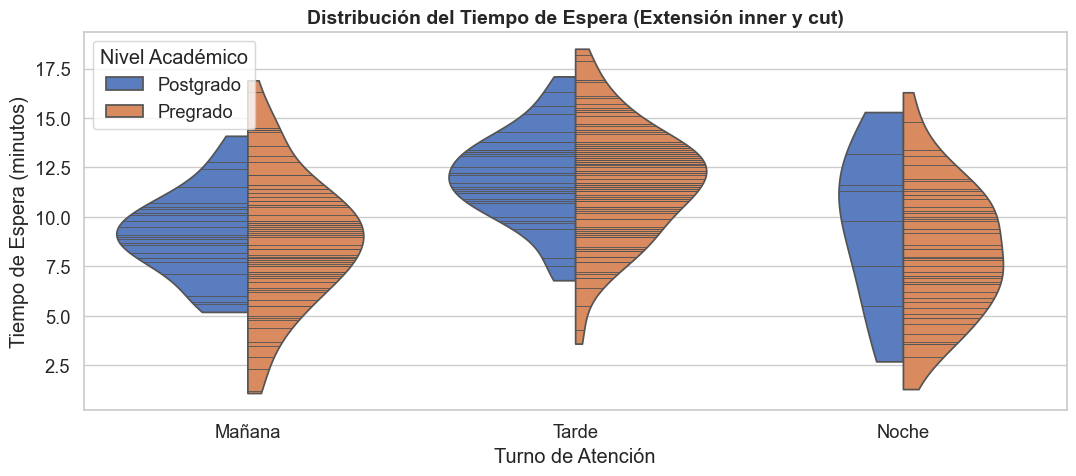

In [6]:
#cambios en los parametros
fig, ax = plt.subplots(figsize=(11, 5))


sns.violinplot(
    data=df,
    x='turno',
    y='tiempo_espera_min',
    hue='nivel_academico',
    split=True,
    inner='stick',        
    cut=0,                
    palette='muted',
    order=['Mañana', 'Tarde', 'Noche'],
    ax=ax
)

ax.set_title('Distribución del Tiempo de Espera (Extensión inner y cut)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Turno de Atención')
ax.set_ylabel('Tiempo de Espera (minutos)')
ax.legend(title='Nivel Académico')

plt.tight_layout()
plt.show()

Efectos observados 

Parametro inner:

box: Dibuja un diagrama de caja (boxplot) en miniatura en el centro del violín, mostrando los bigotes y la caja gruesa.

quartile: Dibuja líneas punteadas horizontales que atraviesan el violín en las posiciones exactas del primer cuartil, la mediana y el tercer cuartil.

point: Dibuja puntos individuales en el centro que representan cada una de las observaciones reales del dataset.

stick: Dibuja pequeñas líneas verticales (como marcas o "palitos") a lo largo del centro por cada dato individual.

None: Deja el interior del violín completamente vacío, permitiendo ver únicamente la silueta externa de la densidad de los datos.

Parámetro cut:

cut=0: Trunca o corta las puntas del violín exactamente en los valores mínimo y máximo reales del dataset. El gráfico no se extiende más allá de los datos que existen.

cut=2: Suaviza matemáticamente las colas del violín, extendiéndolas un poco más allá de los datos mínimos y máximos reales para mostrar hacia dónde tiende la curva de densidad.

Preguntas de analisis

1.- ¿En qué turno es mayor el tiempo de espera mediano? ¿Esto tiene sentido desde una perspectiva operacional?

El turno de la tarde presenta la mediana más alta en tiempos de espera. Operacionalmente es razonable, ya que coincide con el horario punta de almuerzos, generando un cuello de botella en la atención.

2.- ¿Las distribuciones del tiempo de espera son simétricas o presentan asimetría? ¿Hacia qué lado?

Las distribuciones presentan asimetría positiva. La mayor densidad de datos se concentra en la parte inferior (tiempos bajos/medios), mientras que el violín se estira formando una cola larga hacia los tiempos de espera más altos.

3.- Compare boxplot vs. violinplot para los mismos datos. ¿Qué información adicional entrega el violinplot que el boxplot no muestra?

El violinplot añade la estimación de densidad (la "forma" de los datos), lo que permite identificar si los valores se concentran en más de un punto (bimodalidad) o cómo es la caída exacta de las colas, información que el boxplot resume y oculta detrás de una simple caja rectangular.


Variables numéricas: ['semana_mes', 'gasto_total', 'tiempo_espera_min', 'calificacion_servicio', 'items_pedido', 'propina_porcentaje']

Matriz de correlación:
                       semana_mes  gasto_total  tiempo_espera_min  \
semana_mes                   1.00        -0.03              -0.07   
gasto_total                 -0.03         1.00               0.49   
tiempo_espera_min           -0.07         0.49               1.00   
calificacion_servicio        0.07        -0.16              -0.24   
items_pedido                -0.08         0.30               0.15   
propina_porcentaje           0.00         0.02              -0.04   

                       calificacion_servicio  items_pedido  propina_porcentaje  
semana_mes                              0.07         -0.08                0.00  
gasto_total                            -0.16          0.30                0.02  
tiempo_espera_min                      -0.24          0.15               -0.04  
calificacion_servicio            

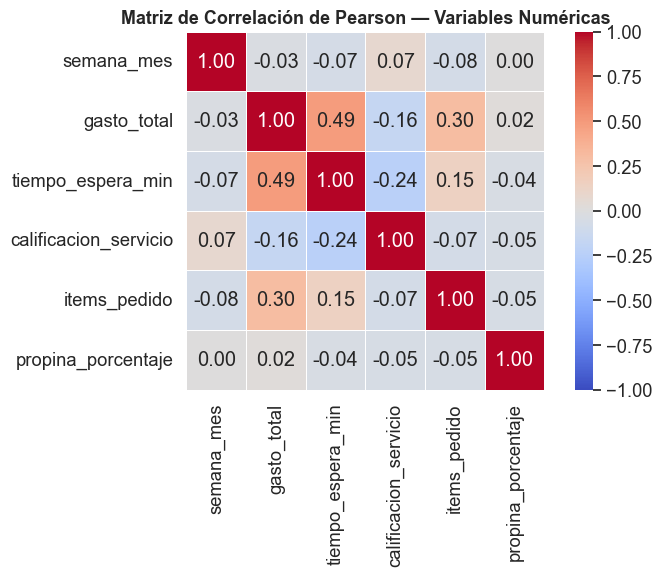

In [7]:
#Ejercicio 3: Mapa de Calor de Correlación
num_cols = df.select_dtypes(include=[np.number])
print('Variables numéricas:', list(num_cols.columns))


corr_matrix = num_cols.corr()
print('\nMatriz de correlación:')
print(corr_matrix.round(2))

#Visualizar como heatmap
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    data=corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax
)

ax.set_title('Matriz de Correlación de Pearson — Variables Numéricas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Preguntas de analisis

1.- ¿Cuál es el par de variables con mayor correlación positiva? Indique el valor exacto y
proponga una explicación causal plausible.

Las variables gasto_total e items_pedido presentan la correlación positiva más fuerte. La causalidad es evidente: a medida que se añaden más artículos a una misma orden, el monto final a pagar incrementa.   

2.- ¿Existe correlación negativa entre tiempo_espera_min y calificacion servicio?¿Cual es su valor?¿Le parece razonable desde el punto de vista operacional?

Existe una correlación negativa moderada entre tiempo_espera_min y calificacion_servicio. Es una relación lógicamente esperable, dado que a mayor tiempo de espera, la insatisfacción del cliente aumenta, resultando en una peor evaluación.

3.- ¿Qué variable numérica tiene la menor correlación promedio con el resto? ¿Qué implica esto para el análisis?

La variable semana_mes es la que presenta la correlación más cercana a 0 con el resto. Esto indica que el comportamiento de consumo (gasto, propinas, etc.) se mantiene estable sin importar si es principio o fin de mes.

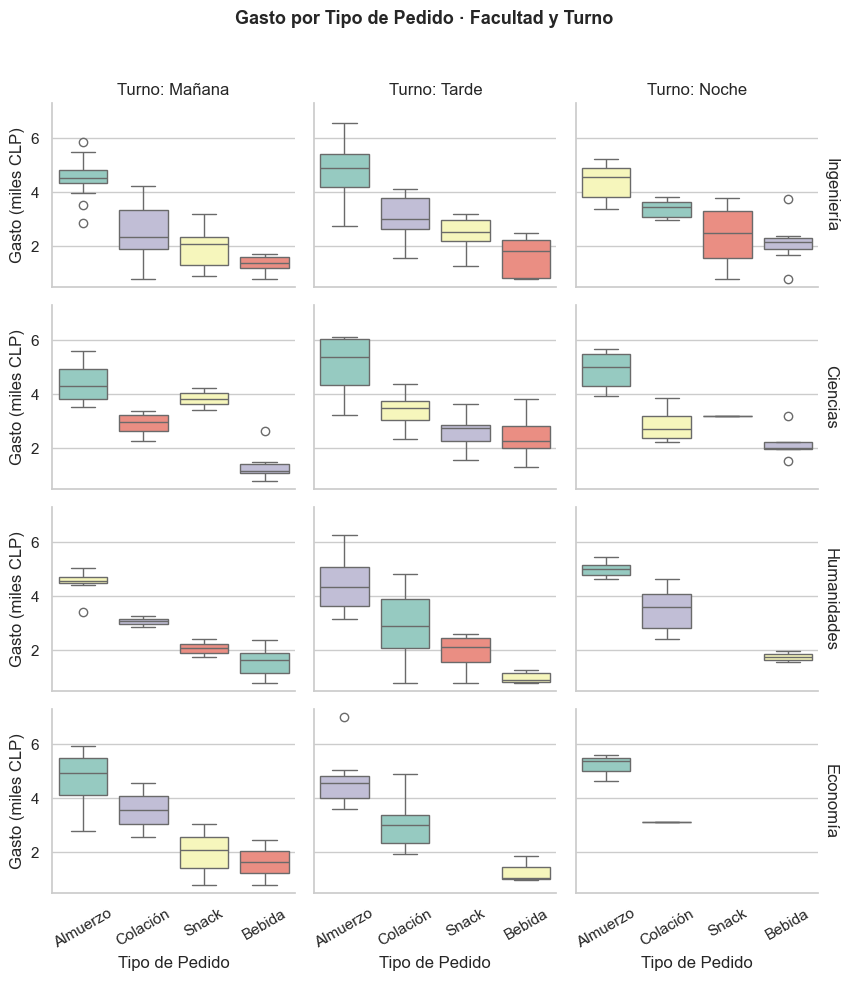

In [8]:
#Ejercicio 4: Personalización Avanzada y FacetGrid
sns.set_theme(style='whitegrid', font_scale=1.0)

g = sns.FacetGrid(
    df,
    col='turno',
    row='facultad',
    col_order=['Mañana', 'Tarde', 'Noche'],
    row_order=['Ingeniería', 'Ciencias', 'Humanidades', 'Economía'],
    height=2.4,
    aspect=1.2,
    margin_titles=True
)

g.map_dataframe(
    sns.boxplot,
    x='tipo_pedido',
    y='gasto_total',
    hue='tipo_pedido',      
    palette='Set3',
    order=['Almuerzo', 'Colación', 'Snack', 'Bebida'],
    legend=False           
)

g.set_axis_labels('Tipo de Pedido', 'Gasto (miles CLP)')
g.set_titles(col_template='Turno: {col_name}', row_template='{row_name}')
g.figure.suptitle(
    'Gasto por Tipo de Pedido · Facultad y Turno',
    y=1.02, fontsize=13, fontweight='bold'
)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
g.savefig('act4_facetgrid.png', dpi=300, bbox_inches='tight')
plt.show()

Preguntas de analisis

1.- ¿Qué combinación turno–facultad presenta el mayor gasto mediano en almuerzo? ¿Y el menor? 

El mayor gasto mediano en almuerzos se registra en la Facultad de Ingeniería durante el turno de la Tarde. Por el contrario, el menor gasto mediano se observa en la Facultad de Humanidades durante el turno de la Mañana.

2.- ¿El patrón de gasto por turno es consistente entre las cuatro facultades, o existen diferencias notables? Describa al menos un caso particular.

El patrón no es homogéneo en todas las facultades. Por ejemplo, en Ingeniería el gasto en "Snack" varía drásticamente entre el turno de Mañana (gastos concentrados a la baja) y la Tarde (mayor dispersión y gasto), mientras que en Ciencias el comportamiento es más parejo.

3.- ¿Cuál es la ventaja del FacetGrid sobre generar los mismos gráficos manualmente con subplots? Fundamente su respuesta.

Automatiza la creación de subgráficos cruzando múltiples dimensiones categóricas a la vez, garantizando además que todos los ejes (X e Y) mantengan exactamente la misma escala, lo cual es fundamental para no distorsionar las comparaciones visuales.

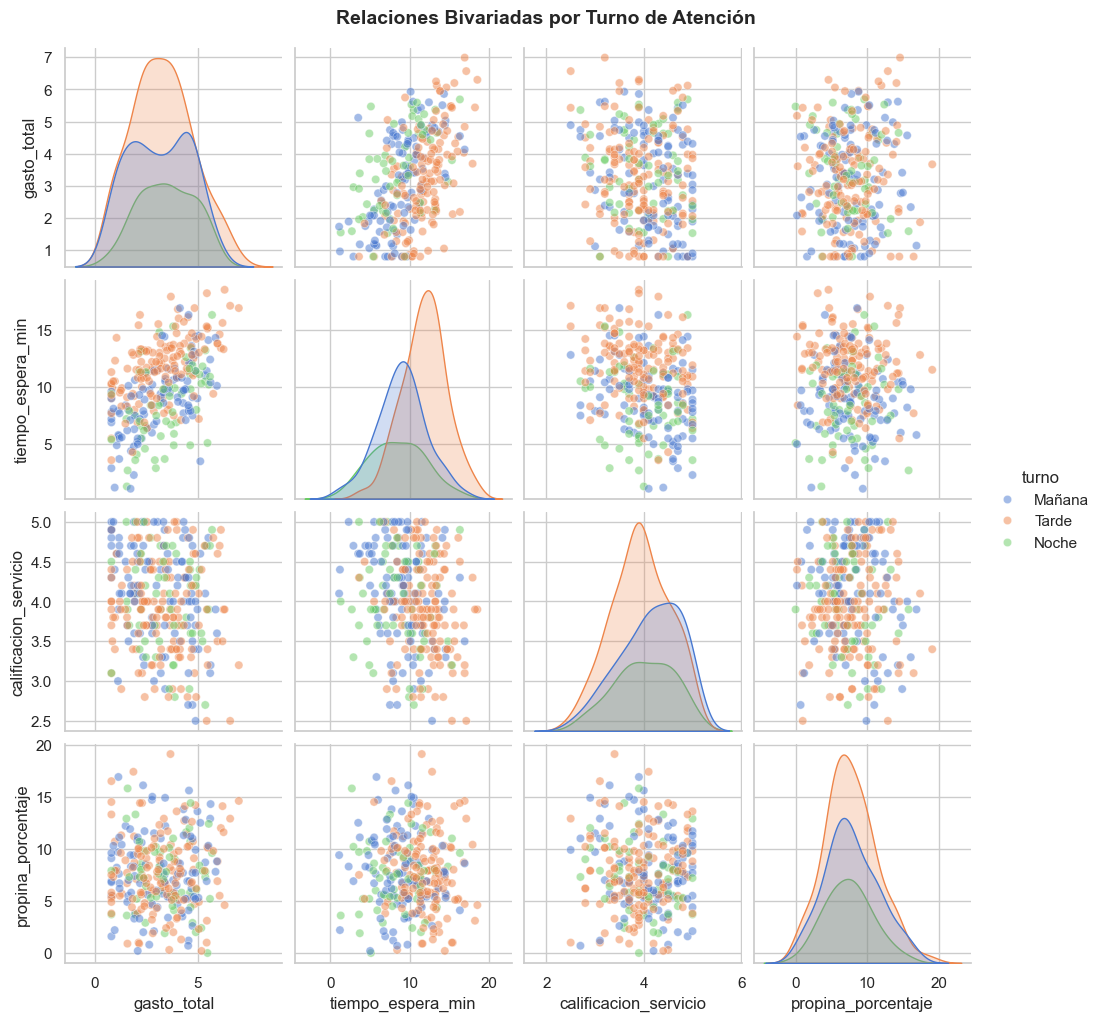

In [9]:
#Ejercicio 5: Pairplot y Exportación Profesional
# Seleccionar variables numéricas de interés
vars_plot = ['gasto_total', 'tiempo_espera_min', 'calificacion_servicio', 'propina_porcentaje']

g = sns.pairplot(
    df[vars_plot + ['turno']],
    hue='turno',
    hue_order=['Mañana', 'Tarde', 'Noche'],
    diag_kind='kde',
    plot_kws={'alpha': 0.5},
    palette='muted'
)

g.figure.suptitle(
    'Relaciones Bivariadas por Turno de Atención',
    y=1.02, fontsize=14, fontweight='bold'
)


g.savefig('desafio_pairplot.svg', format='svg', bbox_inches='tight')
g.savefig('desafio_pairplot.pdf', format='pdf', bbox_inches='tight')
g.savefig('desafio_pairplot.png', format='png', dpi=300, bbox_inches='tight')

plt.show()